C:\Users\abhis\AppData\Local\Temp\ipykernel_33516\2210841202.py:10: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


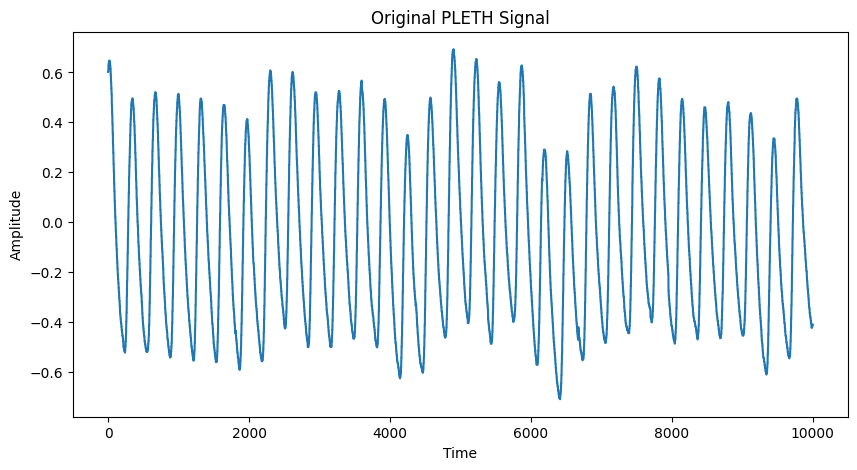

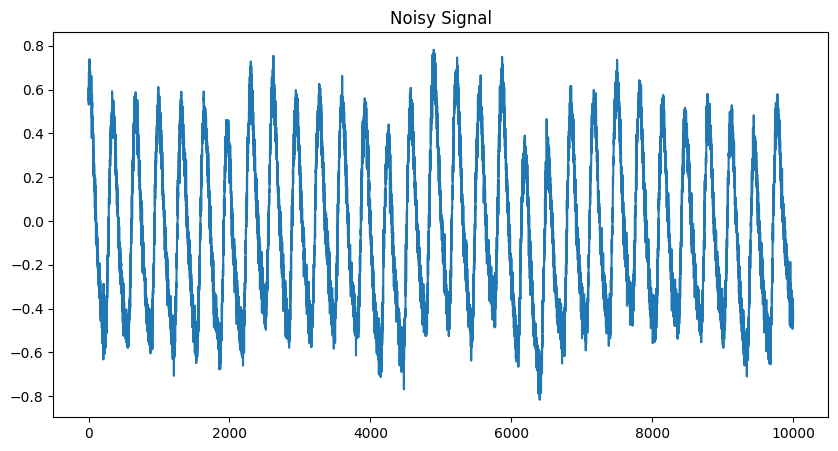

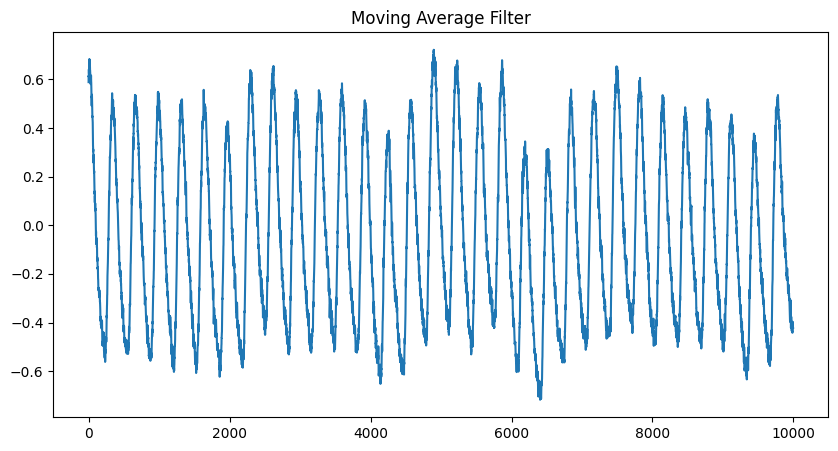

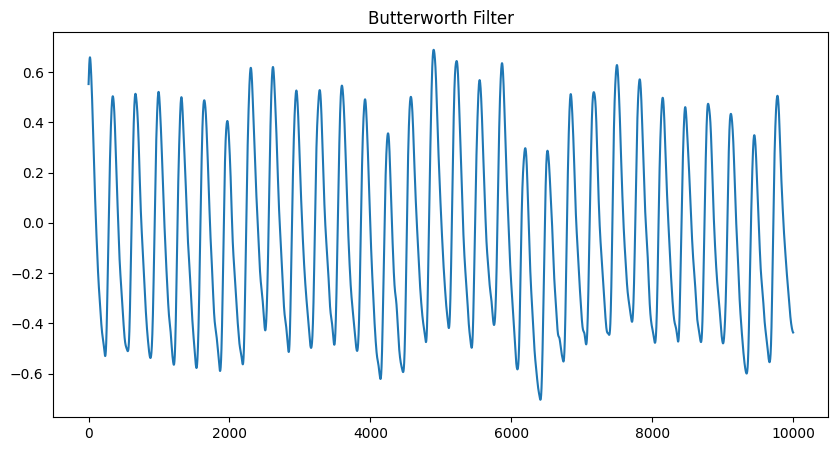

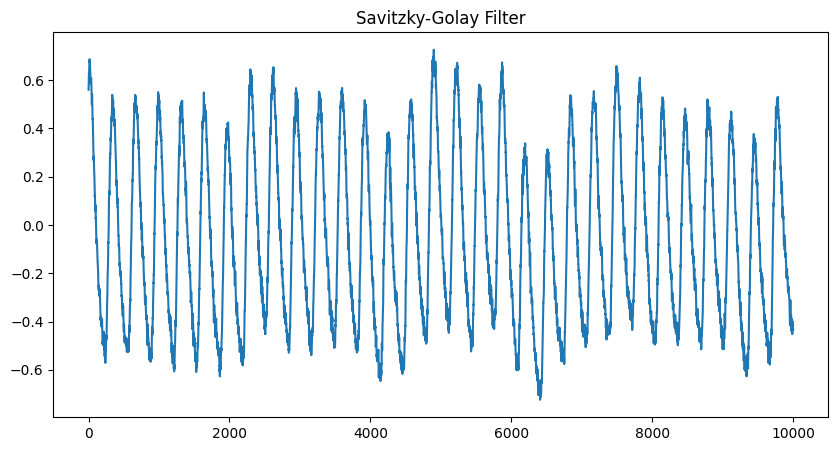

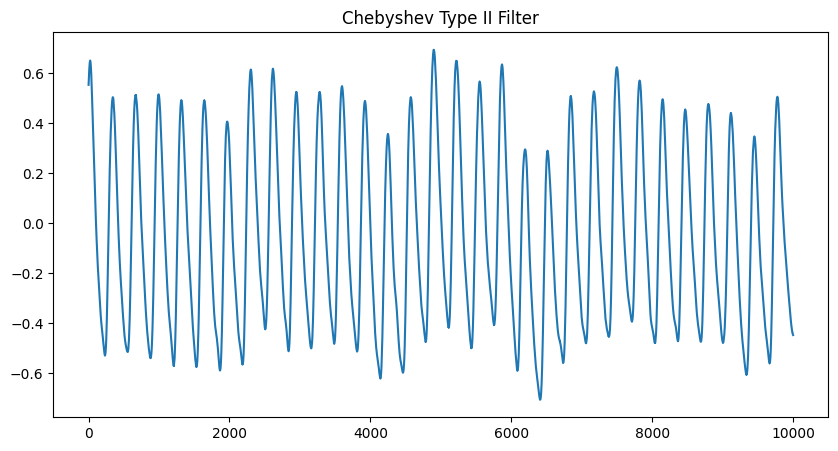

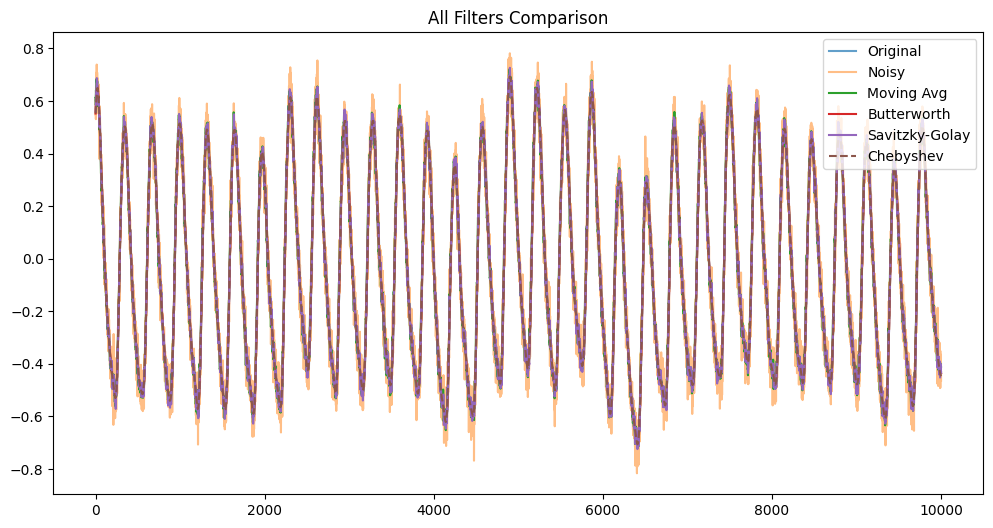

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter, cheby2

# =========================
# 1. LOAD DATASET
# =========================
file_path = "samples2.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip().str.replace("'", "").str.replace(" ", "")

# Convert to numeric and drop NaN
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Take first 10,000 samples
df = df.iloc[:10000]

# =========================
# 2. EXTRACT PLETH SIGNAL
# =========================
pleth_signal = df["PLETH"].values

# =========================
# 3. PLOT ORIGINAL SIGNAL
# =========================
plt.figure(figsize=(10,5))
plt.plot(pleth_signal)
plt.title("Original PLETH Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# =========================
# 4. ADD NOISE
# =========================
noise_std = 0.05
noisy_signal = pleth_signal + np.random.normal(0, noise_std, size=pleth_signal.shape)

# =========================
# 5. PLOT NOISY SIGNAL
# =========================
plt.figure(figsize=(10,5))
plt.plot(noisy_signal)
plt.title("Noisy Signal")
plt.show()

# =========================
# 6. MOVING AVERAGE FILTER
# =========================
window_size = 5
moving_avg = np.convolve(noisy_signal, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(moving_avg)
plt.title("Moving Average Filter")
plt.show()

# =========================
# 7. BUTTERWORTH FILTER
# =========================
def butter_filter(data, cutoff=2, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

butter_output = butter_filter(noisy_signal)

plt.figure(figsize=(10,5))
plt.plot(butter_output)
plt.title("Butterworth Filter")
plt.show()

# =========================
# 8. SAVITZKY-GOLAY FILTER
# =========================
savgol_output = savgol_filter(noisy_signal, window_length=11, polyorder=3)

plt.figure(figsize=(10,5))
plt.plot(savgol_output)
plt.title("Savitzky-Golay Filter")
plt.show()

# =========================
# 9. CHEBYSHEV TYPE II FILTER
# =========================
def cheby_filter(data, cutoff=2, fs=100, order=4, rs=20):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = cheby2(order, rs, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

cheby_output = cheby_filter(noisy_signal)

plt.figure(figsize=(10,5))
plt.plot(cheby_output)
plt.title("Chebyshev Type II Filter")
plt.show()

# =========================
# 10. FINAL COMPARISON GRAPH
# =========================
plt.figure(figsize=(12,6))

plt.plot(pleth_signal, label="Original", alpha=0.7)
plt.plot(noisy_signal, label="Noisy", alpha=0.5)
plt.plot(moving_avg, label="Moving Avg")
plt.plot(butter_output, label="Butterworth")
plt.plot(savgol_output, label="Savitzky-Golay")
plt.plot(cheby_output, label="Chebyshev", linestyle='dashed')

plt.legend()
plt.title("All Filters Comparison")
plt.show()

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ⚠️ Important: Adjust moving average length
min_len = min(len(pleth_signal), len(moving_avg), len(butter_output), len(savgol_output), len(cheby_output))

# Trim all signals to same length
original = pleth_signal[:min_len]
moving_avg_trim = moving_avg[:min_len]
butter_trim = butter_output[:min_len]
savgol_trim = savgol_output[:min_len]
cheby_trim = cheby_output[:min_len]

# =========================
# CALCULATE MSE & MAE
# =========================

results = {}

# Moving Average
results["Moving Average"] = {
    "MSE": mean_squared_error(original, moving_avg_trim),
    "MAE": mean_absolute_error(original, moving_avg_trim)
}

# Butterworth
results["Butterworth"] = {
    "MSE": mean_squared_error(original, butter_trim),
    "MAE": mean_absolute_error(original, butter_trim)
}

# Savitzky-Golay
results["Savitzky-Golay"] = {
    "MSE": mean_squared_error(original, savgol_trim),
    "MAE": mean_absolute_error(original, savgol_trim)
}

# Chebyshev
results["Chebyshev"] = {
    "MSE": mean_squared_error(original, cheby_trim),
    "MAE": mean_absolute_error(original, cheby_trim)
}

# =========================
# PRINT RESULTS
# =========================
print("\nFilter Performance:\n")
for filter_name, values in results.items():
    print(f"{filter_name}: MSE = {values['MSE']:.6f}, MAE = {values['MAE']:.6f}")

# =========================
# FIND BEST FILTER
# =========================
best_filter = min(results, key=lambda x: results[x]["MSE"])

print("\nBest Filter Based on Lowest MSE:", best_filter)


Filter Performance:

Moving Average: MSE = 0.000768, MAE = 0.021949
Butterworth: MSE = 0.000169, MAE = 0.010245
Savitzky-Golay: MSE = 0.000601, MAE = 0.019461
Chebyshev: MSE = 0.000162, MAE = 0.010023

Best Filter Based on Lowest MSE: Chebyshev
